In [13]:
import os 
import sys 
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.pyplot as plt           
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
from netCDF4 import Dataset
import cartopy.io.shapereader as shpreader

import warnings
warnings.filterwarnings("ignore", message="The PyTorch API of nested tensors is in prototype stage")

sys.path.append("/home/users/mendrika/Zambia-Intercomparison/models/training")
from zambia_ensemble_hybrid_improved_multiscale import Core2MapModel

In [14]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
lead_time = 4

# Loading ensemble

In [16]:
ENSEMBLE_DIR = f"/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t{lead_time}"

N_MC = 10  # number of MC dropout samples per model

def enable_dropout(model, p=0.05):
    """
    Enable dropout layers for Monte Carlo sampling, with a custom rate p.
    This keeps the model in eval mode otherwise (BatchNorm, etc.).
    """
    for m in model.modules():
        if isinstance(m, (torch.nn.Dropout, torch.nn.Dropout2d)):
            m.train()  # keep dropout active
            m.p = p    # lower dropout probability (default 0.05)


def load_models(ensemble_dir):
    models = []
    for seed in sorted(os.listdir(ensemble_dir)):
        ckpt = os.path.join(ensemble_dir, seed, "best-core2map.ckpt")
        if os.path.exists(ckpt):
            model = Core2MapModel.load_from_checkpoint(ckpt, map_location=DEVICE)
            model.eval().to(DEVICE)
            models.append(model)
            print(f"Loaded {ckpt}")
    return models

def mc_predict(model, x, g, n_samples=10):
    enable_dropout(model)
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            preds.append(torch.sigmoid(model(x, g)))
    preds = torch.stack(preds)
    return preds.mean(0), preds.var(0)

def ensemble_mc_predict(models, x, g, n_mc=10):
    mean_list, var_list = [], []
    for m in models:
        mean_i, var_i = mc_predict(m, x, g, n_mc)
        mean_list.append(mean_i)
        var_list.append(var_i)
    mean_stack = torch.stack(mean_list)
    var_stack = torch.stack(var_list)
    mean_ens = mean_stack.mean(0)
    var_ens = var_stack.mean(0) + mean_stack.var(0)  # total variance
    return mean_ens, var_ens

In [17]:
models = load_models(ENSEMBLE_DIR)
print(f"Loaded {len(models)} ensemble members.")

Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t4/seed1337/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t4/seed2025/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t4/seed42/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t4/seed777/best-core2map.ckpt
Loaded /gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/checkpoints/ensemble_multiscale_many/sharp/t4/seed999/best-core2map.ckpt
Loaded 5 ensemble members.


# Load scaler

In [18]:
SCALER_PATH = "/gws/nopw/j04/wiser_ewsa/mrakotomanga/Intercomparison/scaling/scaler_realcores.pt"
COLS_TO_SCALE = [0, 1, 2, 3, 4, 5, 6, 7]
MASK_COL_INDEX = 8
LAG_COL_INDEX = 9

scaler = torch.load(SCALER_PATH, weights_only=False)
mean = np.asarray(scaler["mean"])   # shape (8,)
scale = np.asarray(scaler["scale"]) # shape (8,)

# Create dataset

In [19]:
y_min, y_max = 580, 930
x_min, x_max = 1476, 1846

geodata = Dataset("/gws/ssde/j25b/swift/rt_cores/geoloc_grids/nxny2268_2080_nxnyds164580_blobdx0.04491576_arean41_n27_27_79.nc")
Zambia_lons = geodata["lons_mid"][y_min:y_max, x_min:x_max]
Zambia_lats = geodata["lats_mid"][y_min:y_max, x_min:x_max]

In [20]:
# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = -18.414806, -7.9918404
LON_MIN, LON_MAX = 21.167515, 35.316326
NUM_CORES = 288
COLS_TO_SCALE = [0, 1, 2, 3, 4, 5, 6, 7]
MASK_COL_INDEX, LAG_COL_INDEX = 8, 9

# Nowcast origin (change these to adjust the origin time)
year = 2025
month = 10
day = 5
hour = 12
minute = 0

# ---------------------------------------------------------------------
# Zambia city coordinates
# ---------------------------------------------------------------------
locations = {
    "Lusaka": (-15.3875, 28.3228),
    "Ndola": (-12.9683, 28.6366),
    "Kasama": (-10.2129, 31.1808),
    "Chinsali": (-10.5500, 32.0667),
    "Kabwe": (-14.4469, 28.4464),
    "Livingstone": (-17.8419, 25.8542),
    "Mongu": (-15.2484, 23.1274),
    "Mansa": (-11.1996, 28.8943),
    "Solwezi": (-12.1722, 26.3981),
    "Chipata": (-13.6339, 32.6508)
}

# ---------------------------------------------------------------------
# Global context encoding (month and time of day)
# ---------------------------------------------------------------------
def global_context_from(month, hour, minute):
    month_angle = 2 * np.pi * (month - 1) / 12
    tod_angle = 2 * np.pi * (hour + minute / 60.0) / 24
    return torch.tensor([[np.sin(month_angle), np.cos(month_angle),
                          np.sin(tod_angle), np.cos(tod_angle)]], dtype=torch.float32)

# ---------------------------------------------------------------------
# Helpers to build cores
# ---------------------------------------------------------------------
def make_core(lat, lon, tir=-75.0, size=1500.0, lag_minutes=0.0):
    lat = float(np.clip(lat, LAT_MIN, LAT_MAX))
    lon = float(np.clip(lon, LON_MIN, LON_MAX))
    lat_min, lat_max = lat - 0.2, lat + 0.2
    lon_min, lon_max = lon - 0.2, lon + 0.2
    return np.array([lat, lon, lat_min, lat_max, lon_min, lon_max,
                     tir, size, 1.0, lag_minutes], dtype=np.float32)

def make_inactive_filler():
    return np.array([0, 0, 0, 0, 0, 0, 30.0, 0.0, 0.0, 0.0], dtype=np.float32)

def scale_active_columns(X):
    mean_t = torch.tensor(mean, dtype=torch.float32)
    scale_t = torch.tensor(scale, dtype=torch.float32)
    mask = X[:, :, MASK_COL_INDEX] > 0.5
    for c in COLS_TO_SCALE:
        raw = X[:, :, c]
        scaled = (raw - mean_t[c]) / scale_t[c]
        X[:, :, c] = torch.where(mask, scaled, raw)
    X[:, :, LAG_COL_INDEX] = 2 * (X[:, :, LAG_COL_INDEX] / 120.0) - 1.0
    return X

# ---------------------------------------------------------------------
# Build a two-core sample (identical properties)
# ---------------------------------------------------------------------
def build_two_core_sample(city_a="Lusaka", city_b="Ndola",
                          tir=-72.0, size=1400.0,
                          month=month, hour=hour, minute=minute, seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

    X = np.stack([make_inactive_filler() for _ in range(NUM_CORES)], axis=0)

    lat_a, lon_a = locations[city_a]
    lat_b, lon_b = locations[city_b]

    X[0] = make_core(lat_a, lon_a, tir=tir, size=size, lag_minutes=0.0)
    X[1] = make_core(lat_b, lon_b, tir=tir, size=size, lag_minutes=0.0)

    X = torch.tensor(X, dtype=torch.float32).unsqueeze(0)
    G = global_context_from(month=month, hour=hour, minute=minute)
    X = scale_active_columns(X)
    return X, G

# ---------------------------------------------------------------------
# Build a single-core sample
# ---------------------------------------------------------------------
def build_single_core_sample(city, tir=-72.0, size=1400.0,
                             month=month, hour=hour, minute=minute):
    X, G = build_two_core_sample(city_a=city, city_b=city,
                                 tir=tir, size=size,
                                 month=month, hour=hour, minute=minute)
    X[0, 1] = torch.tensor(make_inactive_filler())
    X = scale_active_columns(X)
    return X, G

# ---------------------------------------------------------------------
# Run the interaction test
# ---------------------------------------------------------------------
city_a, city_b = "Lusaka", "Ndola"

X_ab, G = build_two_core_sample(city_a, city_b, month=month, hour=hour, minute=minute)
X_a, _  = build_single_core_sample(city_a, month=month, hour=hour, minute=minute)
X_b, _  = build_single_core_sample(city_b, month=month, hour=hour, minute=minute)

X_ab, X_a, X_b, G = X_ab.to(DEVICE), X_a.to(DEVICE), X_b.to(DEVICE), G.to(DEVICE)


In [21]:
with torch.no_grad():
    M_ab, _ = ensemble_mc_predict(models, X_ab, G)
    M_a,  _ = ensemble_mc_predict(models, X_a,  G)
    M_b,  _ = ensemble_mc_predict(models, X_b,  G)

    # Build empty (no-core) input for baseline
    X_0 = torch.zeros_like(X_a)

    # Fill one dummy token with neutral values (mean-scaled zeros)
    X_0[0, 0, COLS_TO_SCALE] = 0.0     # centred features
    X_0[0, 0, MASK_COL_INDEX] = 1.0    # activate one dummy token
    X_0[0, 0, LAG_COL_INDEX] = -1.0  
    M_0, _ = ensemble_mc_predict(models, X_0, G)


P_ab = M_ab[0,0].cpu().numpy()
P_a  = M_a[0,0].cpu().numpy()
P_b  = M_b[0,0].cpu().numpy()
P_0  = M_0[0,0].cpu().numpy()


# Correct second-order interaction on probability scale
interaction_P = P_ab - P_a - P_b + P_0

# Optional: logit-scale interaction (more linear)
eps = 1e-6
logit = lambda P: np.log((P+eps)/(1-P+eps))
interaction_logit = logit(P_ab) - logit(P_a) - logit(P_b) + logit(P_0)

In [22]:
# need to convert them back to logits but also needs to correct the code to produce logits first and then apply sigmoid

# Plotting

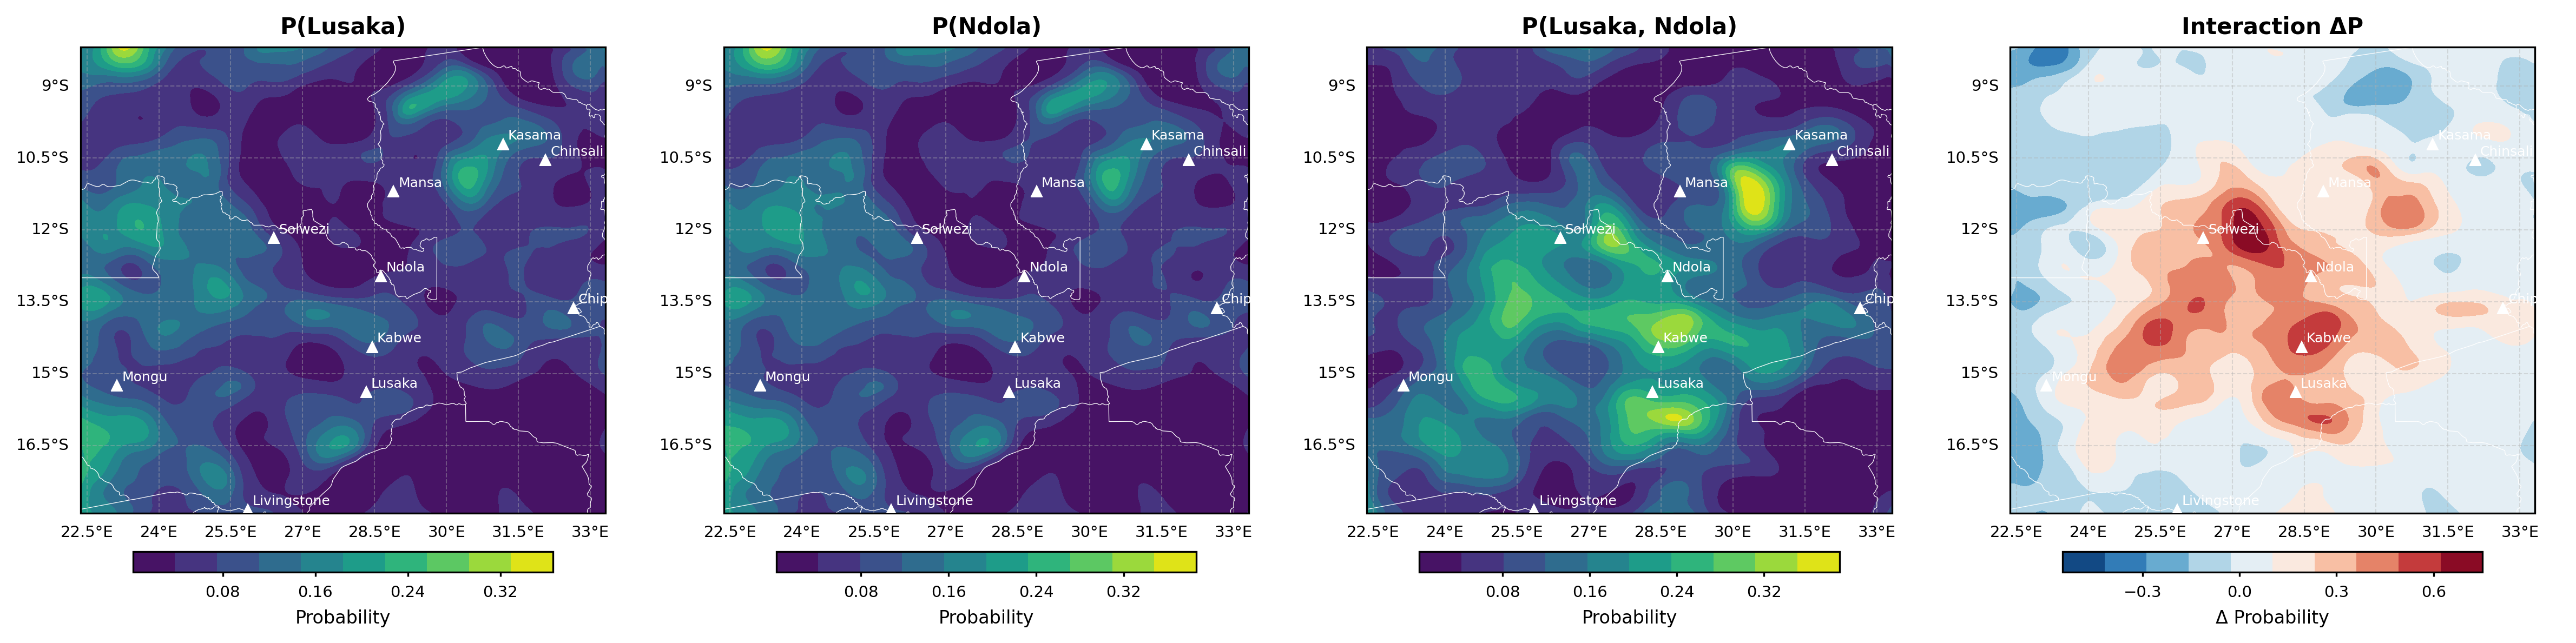

In [23]:
DISPLAY_LON_MIN, DISPLAY_LON_MAX = 21.167515, 35.316326
DISPLAY_LAT_MIN, DISPLAY_LAT_MAX = -18.414806, -7.9918404

# ---------------------------------------------------------------------
# Figure setup
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 4, figsize=(16, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)

# ---------------------------------------------------------------------
# Helper: Add background features and cities
# ---------------------------------------------------------------------
def add_map_features(ax):
    ax.set_extent([DISPLAY_LON_MIN + 1.2, DISPLAY_LON_MAX - 2,
               DISPLAY_LAT_MIN + 0.5, DISPLAY_LAT_MAX - 0.2],
              crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='white', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, alpha=0.4, linestyle='--', linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}
    for name, (lat, lon) in locations.items():
        ax.plot(lon, lat, marker="^", color="white", markersize=4,
                transform=ccrs.PlateCarree(), zorder=6)
        ax.text(lon + 0.1, lat + 0.1, name, fontsize=6,
                transform=ccrs.PlateCarree(), color='white', zorder=6)

# ---------------------------------------------------------------------
# Panels (auto range + simplified colourbars)
# ---------------------------------------------------------------------
maps = [
    (P_a, f"P({city_a})", 'viridis'),
    (P_b, f"P({city_b})", 'viridis'),
    (P_ab, f"P({city_a}, {city_b})", 'viridis'),
    (interaction_P, "Interaction ΔP", 'RdBu_r')
]

for ax, (data, title, cmap) in zip(axes, maps):
    add_map_features(ax)
    # Auto levels but with fewer steps for smoother bars
    levels = np.linspace(np.nanmin(data), np.nanmax(data), 11)
    im = ax.contourf(
        Zambia_lons, Zambia_lats, data,
        levels=levels, cmap=cmap,
        transform=ccrs.PlateCarree()
    )
    ax.set_title(title, fontsize=10, weight='bold')
    
    # Compact, readable colourbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.05)
    cbar.set_label("Δ Probability" if "Δ" in title else "Probability", fontsize=8)
    cbar.ax.tick_params(labelsize=7, length=2)
    # Auto-limit to max ~5 ticks for readability
    cbar.locator = plt.MaxNLocator(nbins=5)
    cbar.update_ticks()
    # Use scientific notation if range is very small
    if np.abs(np.nanmax(data) - np.nanmin(data)) < 1e-2:
        cbar.formatter.set_powerlimits((-2, 2))
        cbar.update_ticks()

plt.tight_layout()
plt.show()


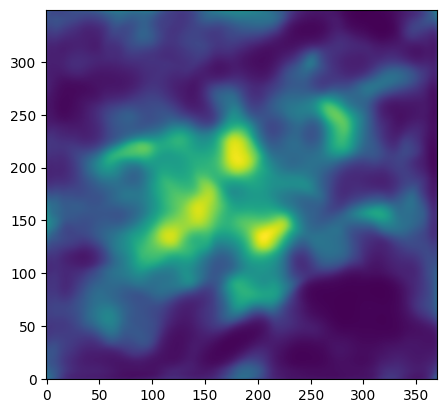

In [24]:
plt.imshow(P_0, origin="lower")
plt.show()